# 🧠 พื้นฐาน Machine Learning — จาก Neuron เดียว สู่ Transformer

Notebook นี้พาไล่ตั้งแต่พื้นฐานที่สุดของ Machine Learning ไปจนถึงหัวใจของ LLM สมัยใหม่
โดยเริ่มจาก **เขียนเองทุกบรรทัด** (ไม่ใช้ library สำหรับ ML) แล้วค่อย ๆ ขยับไปใช้เครื่องมือจริง

| Part | เนื้อหา | เครื่องมือ |
|---|---|---|
| 0 | Linear Regression — gradient descent ที่เห็นภาพง่ายที่สุด | NumPy |
| 1 | Neuron เดี่ยว — และทำไมมันแก้ปัญหา XOR ไม่ได้ | NumPy (คำนวณเองทุกขั้น) |
| 2 | MLP แก้ XOR — forward / backprop เขียนเองล้วน ๆ | Pure Python (ไม่มีแม้แต่ NumPy) |
| 3 | MLP เวอร์ชัน Vectorized — คิดเป็น matrix | NumPy |
| 4 | งานเดียวกันด้วย TensorFlow / Keras + ตัวอย่างจริง (MNIST) | TensorFlow |
| 5 | Overfitting / Underfitting — ปัญหากลางของ ML ทั้งวงการ | NumPy + TensorFlow |
| 6 | CNN — สถาปัตยกรรมสำหรับรูปภาพ + Confusion Matrix | TensorFlow |
| 7 | Attention Mechanism — หัวใจของ Transformer (เขียนเองด้วย NumPy) | NumPy |
| 8 | Mini LLM — สร้าง GPT จิ๋วระดับตัวอักษร แล้ว generate ข้อความจริง | TensorFlow |

> **แนวคิดหลักของทั้ง notebook:** โมเดลทุกตัวในนี้ ตั้งแต่เส้นตรงเส้นเดียวจนถึง LLM ทำงานด้วยวงจรเดียวกันหมด
>
> **forward คำนวณคำตอบ → วัด loss → backprop หา gradient → ปรับ weight → วนซ้ำ**
>
> สิ่งที่ต่างกันคือ "สถาปัตยกรรม" ที่เอาชิ้นส่วนมาประกอบกันเท่านั้น

In [1]:
# ── Setup กลางของทั้ง notebook ──────────────────────────────────────
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"   # ปิด log ที่ไม่จำเป็นของ TensorFlow (ต้องตั้งก่อน import tf)

import math
import random
import numpy as np
import matplotlib.pyplot as plt

# ใช้ฟอนต์ที่มีอักษรไทย (มากับ Windows) — ไม่งั้นข้อความไทยใน plot จะเป็นกล่องสี่เหลี่ยม
plt.rcParams["font.family"] = "Tahoma"
plt.rcParams["axes.unicode_minus"] = False

# fix random seed เพื่อให้รันซ้ำแล้วได้ผลเดิม (reproducibility)
random.seed(42)
np.random.seed(42)

---
## Part 0 — Linear Regression: gradient descent ที่เห็นภาพง่ายที่สุด

ก่อนไปถึง neural network เริ่มจากโจทย์ที่เล็กที่สุดของ ML: **ลากเส้นตรงผ่านข้อมูล**

มีจุดข้อมูล $(x, y)$ ที่แอบสร้างมาจาก $y = 2x + 1 + \text{noise}$ — โมเดลต้อง "ค้นพบ" เลข 2 กับ 1 ด้วยตัวเอง

$$\hat{y} = wx + b$$

วัดความผิดพลาดด้วย Mean Squared Error:

$$L = \frac{1}{N}\sum_i (\hat{y}_i - y_i)^2$$

แล้วใช้ **gradient descent**: หาความชันของ loss เทียบกับ $w, b$ แล้วเดิน "ลงเขา" ทีละก้าวเล็ก ๆ

$$\frac{\partial L}{\partial w} = \frac{2}{N}\sum_i (\hat{y}_i - y_i)\,x_i \qquad\qquad \frac{\partial L}{\partial b} = \frac{2}{N}\sum_i (\hat{y}_i - y_i)$$

วงจร **forward → loss → gradient → update** ที่เห็นตรงนี้ คือวงจรเดียวกับที่ใช้ train ทุกโมเดลใน notebook นี้ รวมถึง LLM

โมเดลค้นพบ:  w = 1.911 (ความจริง 2.0),  b = 1.099 (ความจริง 1.0)


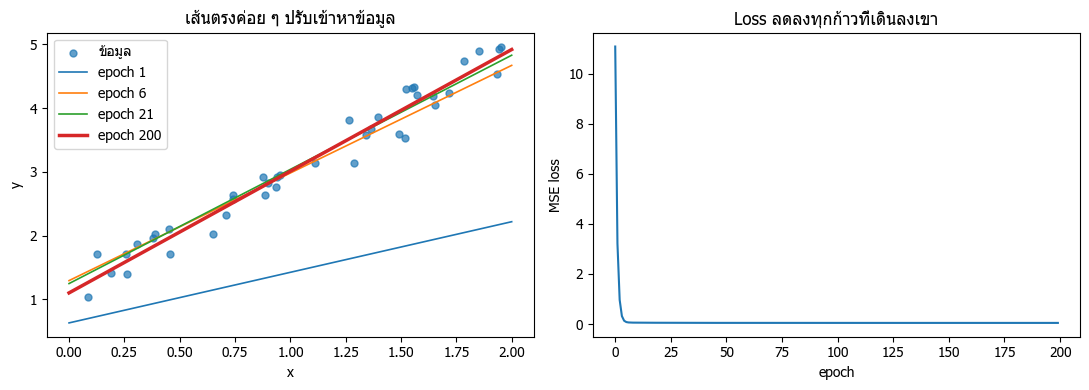

In [2]:
# ── Linear Regression ด้วย gradient descent เขียนเอง ──
rng0 = np.random.default_rng(42)

# สร้างข้อมูล: ความจริงคือ y = 2x + 1 แต่มี noise ปน (โมเดลไม่รู้ความจริงนี้)
x_lin = rng0.uniform(0, 2, 40)
y_lin = 2.0 * x_lin + 1.0 + rng0.normal(0, 0.3, 40)

w_lin, b_lin = 0.0, 0.0      # เริ่มจากเส้นที่ผิดสนิท (เส้นนอนทับแกน x)
lr = 0.1                     # learning rate — ขนาดก้าวที่เดินลงเขา
lin_loss_hist = []
snapshots = {}               # เก็บเส้น ณ บาง epoch ไว้วาดรูป

for epoch in range(200):
    y_pred = w_lin * x_lin + b_lin              # forward: ทำนายด้วยเส้นปัจจุบัน
    err = y_pred - y_lin
    lin_loss_hist.append(np.mean(err ** 2))     # loss: MSE

    dw = 2 * np.mean(err * x_lin)               # gradient: dL/dw
    db = 2 * np.mean(err)                       # gradient: dL/db
    w_lin -= lr * dw                            # update: เดินสวนทาง gradient
    b_lin -= lr * db

    if epoch in (0, 5, 20):
        snapshots[epoch + 1] = (w_lin, b_lin)
snapshots[200] = (w_lin, b_lin)

print(f"โมเดลค้นพบ:  w = {w_lin:.3f} (ความจริง 2.0),  b = {b_lin:.3f} (ความจริง 1.0)")

# ── วาด: เส้นค่อย ๆ ขยับเข้าหาข้อมูล และ loss ที่ลดลง ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(x_lin, y_lin, s=25, alpha=0.7, label="ข้อมูล")
xs = np.array([0, 2])
for ep, (w_s, b_s) in snapshots.items():
    axes[0].plot(xs, w_s * xs + b_s, label=f"epoch {ep}",
                 lw=2.5 if ep == 200 else 1.2)
axes[0].legend()
axes[0].set_xlabel("x"); axes[0].set_ylabel("y")
axes[0].set_title("เส้นตรงค่อย ๆ ปรับเข้าหาข้อมูล")

axes[1].plot(lin_loss_hist)
axes[1].set_xlabel("epoch"); axes[1].set_ylabel("MSE loss")
axes[1].set_title("Loss ลดลงทุกก้าวที่เดินลงเขา")
plt.tight_layout()
plt.show()

โมเดลหา $w \approx 2,\ b \approx 1$ เจอเองโดยไม่มีใครบอก — และ neuron เดี่ยวใน Part 1 ถัดไป
ก็คือ linear regression ตัวนี้ + เพิ่ม input เป็น 2 ตัว + ครอบ sigmoid เท่านั้นเอง

---
## Part 1 — Neuron เดี่ยว และข้อจำกัดของมัน

Neuron 1 ตัว (ถ้าใช้ sigmoid ก็คือ *logistic regression* นั่นเอง) คำนวณแค่ 2 ขั้น:

$$z = w_1 x_1 + w_2 x_2 + b \qquad \text{(ผลรวมถ่วงน้ำหนัก)}$$

$$\hat{y} = \sigma(z) = \frac{1}{1+e^{-z}} \qquad \text{(activation — บีบให้อยู่ระหว่าง 0 ถึง 1)}$$

- $w$ (weight) = ความสำคัญของ input แต่ละตัว — **นี่คือสิ่งที่โมเดล "เรียนรู้"**
- $b$ (bias) = ค่าเลื่อนฐานของ neuron
- $\sigma$ (sigmoid) = ทำให้ผลลัพธ์ตีความเป็น "ความน่าจะเป็น" ได้

**จุดสำคัญ:** เส้นแบ่งการตัดสินใจ (decision boundary) ของ neuron เดียวคือจุดที่ $z = 0$
ซึ่งเป็นสมการ**เส้นตรงเสมอ** → แก้ได้เฉพาะปัญหาที่ลากเส้นตรงเส้นเดียวแบ่ง class ได้ (*linearly separable*)

ลองกับ logic gate 2 โจทย์:

| $x_1$ | $x_2$ | OR | **XOR** |
|:-:|:-:|:-:|:-:|
| 0 | 0 | 0 | 0 |
| 0 | 1 | 1 | **1** |
| 1 | 0 | 1 | **1** |
| 1 | 1 | 1 | **0** |

OR ลากเส้นตรงแบ่งได้ แต่ XOR (จุดทแยงมุมเป็น class เดียวกัน) **แบ่งไม่ได้** — พิสูจน์ด้วยการ train จริงกันเลย

In [3]:
# ── Neuron เดี่ยว: เขียน forward + gradient descent เองทั้งหมด ──

def sigmoid(x):
    """activation function: บีบค่าใด ๆ ให้อยู่ในช่วง (0, 1)"""
    return 1.0 / (1.0 + np.exp(-x))

def train_single_neuron(X, y, lr=0.5, epochs=5000):
    """train neuron 1 ตัวด้วย gradient descent (loss = squared error)"""
    rng = np.random.default_rng(0)
    w = rng.uniform(-1, 1, size=2)   # weight 2 ตัว (ตามจำนวน input)
    b = 0.0                          # bias

    for _ in range(epochs):
        for xi, yi in zip(X, y):     # ดูข้อมูลทีละตัวอย่าง (stochastic gradient descent)
            # --- forward: คำนวณคำตอบของโมเดล ณ ตอนนี้ ---
            z = w @ xi + b           # ผลรวมถ่วงน้ำหนัก  z = w1*x1 + w2*x2 + b
            y_pred = sigmoid(z)

            # --- backward: หา gradient ด้วย chain rule ---
            # loss L = (y_pred - y)^2
            # dL/dz  = dL/dy_pred * dy_pred/dz = 2(y_pred - y) * sigmoid'(z)
            # โดยอนุพันธ์ของ sigmoid คือ  sigmoid'(z) = sigmoid(z) * (1 - sigmoid(z))
            dz = 2 * (y_pred - yi) * y_pred * (1 - y_pred)
            dw = dz * xi             # dL/dw = dL/dz * dz/dw   (เพราะ dz/dw = x)
            db = dz                  # dL/db = dL/dz           (เพราะ dz/db = 1)

            # --- update: ขยับ weight "สวนทาง" gradient เพื่อลด loss ---
            w -= lr * dw
            b -= lr * db
    return w, b

X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)
y_or  = np.array([0,1,1,1], dtype=float)   # โจทย์ OR  — แบ่งด้วยเส้นตรงได้
y_xor = np.array([0,1,1,0], dtype=float)   # โจทย์ XOR — แบ่งด้วยเส้นตรงไม่ได้

for name, y_target in [("OR", y_or), ("XOR", y_xor)]:
    w, b = train_single_neuron(X, y_target)
    preds = sigmoid(X @ w + b)
    acc = np.mean((preds > 0.5) == y_target) * 100
    print(f"โจทย์ {name}:  accuracy = {acc:.0f}%")
    for xi, yi, p in zip(X, y_target, preds):
        print(f"   input {xi.astype(int).tolist()}  →  pred {p:.3f}   (เฉลย {int(yi)})")
    print()

โจทย์ OR:  accuracy = 100%
   input [0, 0]  →  pred 0.023   (เฉลย 0)
   input [0, 1]  →  pred 0.985   (เฉลย 1)
   input [1, 0]  →  pred 0.985   (เฉลย 1)
   input [1, 1]  →  pred 1.000   (เฉลย 1)



โจทย์ XOR:  accuracy = 25%
   input [0, 0]  →  pred 0.533   (เฉลย 0)
   input [0, 1]  →  pred 0.500   (เฉลย 1)
   input [1, 0]  →  pred 0.467   (เฉลย 1)
   input [1, 1]  →  pred 0.434   (เฉลย 0)



ผลที่ได้: **OR ทำนายถูกหมด** แต่ **XOR ทำนายออกมา ~0.5 ทุกตัว** — โมเดล "ยอมแพ้" แล้วตอบกลาง ๆ
เพราะไม่ว่าจะหมุนเส้นตรงไปมุมไหน ก็แบ่ง 4 จุดของ XOR ให้ถูกครบไม่ได้ ดูเป็นภาพ:

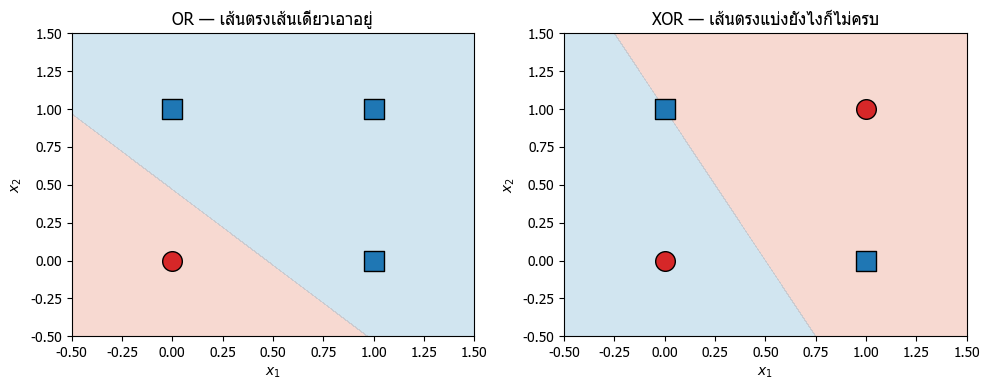

In [4]:
# ── วาด decision boundary: ทำไม OR แบ่งได้ แต่ XOR แบ่งไม่ได้ ──
fig, axes = plt.subplots(1, 2, figsize=(10, 4))

for ax, name, y_target in [(axes[0], "OR", y_or), (axes[1], "XOR", y_xor)]:
    w, b = train_single_neuron(X, y_target)

    # ระบายสีพื้นหลังตามคำทำนายของ neuron — รอยต่อของสีคือ decision boundary
    xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
    grid = np.c_[xx.ravel(), yy.ravel()]                  # ทุกจุดบนระนาบ
    zz = sigmoid(grid @ w + b).reshape(xx.shape)          # คำทำนายของทุกจุด
    ax.contourf(xx, yy, zz, levels=[0, 0.5, 1], cmap="RdBu", alpha=0.3)

    # จุดข้อมูลจริง: วงกลมแดง = class 0, สี่เหลี่ยมน้ำเงิน = class 1
    for xi, yi in zip(X, y_target):
        marker, color = ("s", "tab:blue") if yi == 1 else ("o", "tab:red")
        ax.scatter(*xi, marker=marker, c=color, s=200, edgecolors="k", zorder=3)
    ax.set_title(f"{name} — " + ("เส้นตรงเส้นเดียวเอาอยู่" if name == "OR" else "เส้นตรงแบ่งยังไงก็ไม่ครบ"))
    ax.set_xlabel("$x_1$"); ax.set_ylabel("$x_2$")

plt.tight_layout()
plt.show()

---
## Part 2 — MLP แก้ XOR (Pure Python — ไม่ใช้ library เลย)

ทางออกคือเพิ่ม **hidden layer** กลายเป็น Multi-Layer Perceptron (MLP):

- neuron เดียว = เส้นตรง 1 เส้น → ไม่พอ
- hidden neuron 2 ตัว = เส้นตรง 2 เส้น แล้วให้ output neuron "รวมผล" → ได้เขตแบ่งที่โค้งงอได้

สถาปัตยกรรม **2 → 2 → 1** (input 2 ตัว, hidden 2 ตัว, output 1 ตัว):

```
x₁ ──┬─────→ (h₁) ──┬─────→ (out) → ŷ
     ╳              │
x₂ ──┴─────→ (h₂) ──┘
```

**Forward pass** — คำนวณจากซ้ายไปขวา:

$$z^{(1)}_j = \sum_i x_i W^{(1)}_{ij} + b^{(1)}_j \,,\qquad a^{(1)}_j = \sigma(z^{(1)}_j)$$

$$z^{(2)} = \sum_j a^{(1)}_j W^{(2)}_j + b^{(2)} \,,\qquad \hat{y} = \sigma(z^{(2)})$$

**Backward pass (backpropagation)** — ใช้ **chain rule** ไล่ gradient จาก loss ย้อนกลับทีละชั้น
(ใช้ loss $L = \tfrac{1}{2}(\hat{y}-y)^2$ — ใส่ ½ ไว้ให้อนุพันธ์ออกมาสวย):

$$\delta^{(2)} = \frac{\partial L}{\partial z^{(2)}} = (\hat{y}-y)\;\hat{y}(1-\hat{y}) \qquad \text{← delta ของชั้น output}$$

$$\delta^{(1)}_j = \delta^{(2)}\; W^{(2)}_j\; a^{(1)}_j(1-a^{(1)}_j) \qquad \text{← delta ของชั้น hidden (ส่งย้อนผ่าน } W^{(2)})$$

gradient ของ weight แต่ละตัว = `delta ของชั้นนั้น × input ของชั้นนั้น` แล้ว update:

$$W \;\leftarrow\; W - \eta \,\frac{\partial L}{\partial W} \qquad (\eta = \text{learning rate})$$

In [5]:
# ── XOR MLP (2-2-1) — Pure Python: ใช้แค่ math กับ random ──
random.seed(42)

def sig(x):
    """sigmoid เวอร์ชัน pure python"""
    return 1.0 / (1.0 + math.exp(-x))

# ----- ข้อมูล XOR -----
X_xor = [[0,0],[0,1],[1,0],[1,1]]
y_xor_list = [0, 1, 1, 0]

# ----- สุ่ม weight เริ่มต้น (ค่าเล็ก ๆ รอบศูนย์) -----
rand = lambda: random.uniform(-1.0, 1.0)
W1 = [[rand(), rand()],   # W1[i][j] = weight จาก input i → hidden j
      [rand(), rand()]]
b1 = [rand(), rand()]     # bias ของ hidden แต่ละตัว
W2 = [rand(), rand()]     # W2[j]    = weight จาก hidden j → output
b2 = rand()               # bias ของ output

def forward(x):
    """forward pass: คืน activation ทุกชั้น (ต้องเก็บไว้ใช้ตอน backward)"""
    # ชั้น hidden:  z1[j] = x1*W1[0][j] + x2*W1[1][j] + b1[j]
    z1 = [x[0]*W1[0][j] + x[1]*W1[1][j] + b1[j] for j in range(2)]
    a1 = [sig(z) for z in z1]                    # activation ของ hidden
    # ชั้น output:  z2 = a1·W2 + b2
    z2 = a1[0]*W2[0] + a1[1]*W2[1] + b2
    a2 = sig(z2)                                 # คำตอบสุดท้ายของโมเดล
    return a1, a2

def backward_and_update(x, y_true, a1, a2, lr):
    """backprop: ไล่ gradient จาก output ย้อนกลับมา แล้ว update weight ทันที"""
    global b2
    # delta ชั้น output = dL/dz2   (จาก L = ½(a2-y)² และ sigmoid')
    delta2 = (a2 - y_true) * a2 * (1 - a2)

    # delta ชั้น hidden = ส่ง delta2 ย้อนผ่าน W2 แล้วคูณ sigmoid' ของชั้นตัวเอง
    delta1 = [delta2 * W2[j] * a1[j] * (1 - a1[j]) for j in range(2)]

    # ----- update ชั้น output:  dL/dW2[j] = delta2 * a1[j] -----
    for j in range(2):
        W2[j] -= lr * delta2 * a1[j]
    b2 -= lr * delta2

    # ----- update ชั้น hidden:  dL/dW1[i][j] = delta1[j] * x[i] -----
    for i in range(2):
        for j in range(2):
            W1[i][j] -= lr * delta1[j] * x[i]
    for j in range(2):
        b1[j] -= lr * delta1[j]

# ----- training loop: วงจร forward → loss → backward → update ซ้ำ ๆ -----
LR, EPOCHS = 1.0, 10_000
for epoch in range(EPOCHS + 1):
    sq_err = 0.0
    for xi, yi in zip(X_xor, y_xor_list):
        a1, a2 = forward(xi)
        sq_err += (a2 - yi) ** 2
        backward_and_update(xi, yi, a1, a2, LR)
    if epoch % 2000 == 0:
        print(f"epoch {epoch:>6}   MSE = {sq_err/4:.6f}")

print("\nผลทดสอบหลัง train:")
for xi, yi in zip(X_xor, y_xor_list):
    _, pred = forward(xi)
    print(f"  {xi} → {pred:.4f}   (ปัดเป็น {round(pred)}, เฉลย {yi})  {'✔' if round(pred)==yi else '✘'}")

epoch      0   MSE = 0.276758
epoch   2000   MSE = 0.000895
epoch   4000   MSE = 0.000381
epoch   6000   MSE = 0.000239
epoch   8000   MSE = 0.000173


epoch  10000   MSE = 0.000136

ผลทดสอบหลัง train:
  [0, 0] → 0.0106   (ปัดเป็น 0, เฉลย 0)  ✔
  [0, 1] → 0.9889   (ปัดเป็น 1, เฉลย 1)  ✔
  [1, 0] → 0.9889   (ปัดเป็น 1, เฉลย 1)  ✔
  [1, 1] → 0.0136   (ปัดเป็น 0, เฉลย 0)  ✔


---
## Part 3 — เวอร์ชัน NumPy: คิดเป็น Matrix (Vectorization)

Part 2 ใช้ loop วนทีละ neuron ทีละตัวอย่าง — ช้าและขยายสเกลไม่ไหว
ความจริงทั้งชั้น (และทั้ง batch ของข้อมูล) คำนวณพร้อมกันได้ด้วย**การคูณ matrix ครั้งเดียว**:

$$Z^{(1)} = X W^{(1)} + b^{(1)} \qquad A^{(1)} = \sigma(Z^{(1)})$$

$$Z^{(2)} = A^{(1)} W^{(2)} + b^{(2)} \qquad \hat{Y} = \sigma(Z^{(2)})$$

shape ของแต่ละตัว (N = จำนวนตัวอย่าง, H = จำนวน hidden neuron):

| ตัวแปร | shape | ความหมาย |
|---|---|---|
| $X$ | (N, 2) | ข้อมูล**ทุกตัวอย่าง**ซ้อนกันเป็นแถว |
| $W^{(1)}$ | (2, H) | weight ชั้น hidden ทุกตัวในก้อนเดียว |
| $A^{(1)}$ | (N, H) | activation ของ hidden ทุกตัว ทุกตัวอย่าง |
| $W^{(2)}$ | (H, 1) | weight ชั้น output |
| $\hat{Y}$ | (N, 1) | คำตอบของทุกตัวอย่างพร้อมกัน |

นี่คือเหตุผลที่ GPU เร่ง deep learning ได้มหาศาล — **ทุกอย่างในโมเดลคือการคูณ matrix**

In [6]:
# ── XOR MLP ด้วย NumPy: ทั้ง batch คำนวณพร้อมกันในครั้งเดียว ──
X = np.array([[0,0],[0,1],[1,0],[1,1]], dtype=float)    # (4, 2)
Y = np.array([[0],[1],[1],[0]], dtype=float)             # (4, 1)

H, LR = 4, 2.0            # hidden 4 ตัว (เผื่อไว้ ช่วยให้ converge ง่าย), learning rate
rng = np.random.default_rng(1)
W1 = rng.uniform(-1, 1, (2, H));  b1 = np.zeros(H)       # weight + bias ชั้น hidden
W2 = rng.uniform(-1, 1, (H, 1));  b2 = np.zeros(1)       # weight + bias ชั้น output

loss_history = []
for epoch in range(5000):
    # ---------- forward: ทุกตัวอย่างพร้อมกันใน matrix เดียว ----------
    Z1 = X @ W1 + b1          # (4, H)  pre-activation ชั้น hidden
    A1 = sigmoid(Z1)          # (4, H)  activation ชั้น hidden
    Z2 = A1 @ W2 + b2         # (4, 1)  pre-activation ชั้น output
    A2 = sigmoid(Z2)          # (4, 1)  คำทำนายทั้ง 4 ตัวอย่าง

    loss = np.mean((A2 - Y) ** 2)        # MSE เฉลี่ยทั้ง batch
    loss_history.append(loss)

    # ---------- backward: chain rule เดิมจาก Part 2 แต่อยู่ในรูป matrix ----------
    dZ2 = (A2 - Y) * A2 * (1 - A2) / len(X)   # (4, 1)  delta ชั้น output (เฉลี่ยด้วย N)
    dW2 = A1.T @ dZ2                           # (H, 1)  gradient = inputᵀ @ delta
    db2 = dZ2.sum(axis=0)                      # (1,)

    dZ1 = (dZ2 @ W2.T) * A1 * (1 - A1)         # (4, H)  ส่ง delta ย้อนผ่าน W2
    dW1 = X.T @ dZ1                            # (2, H)
    db1 = dZ1.sum(axis=0)                      # (H,)

    # ---------- update: gradient descent ----------
    W1 -= LR * dW1;  b1 -= LR * db1
    W2 -= LR * dW2;  b2 -= LR * db2

print(f"loss เริ่มต้น {loss_history[0]:.4f}  →  สุดท้าย {loss_history[-1]:.6f}\n")
for xi, yi, pi in zip(X, Y, A2):
    print(f"  {xi.astype(int).tolist()} → {pi[0]:.4f}   (เฉลย {int(yi[0])})")

loss เริ่มต้น 0.2536  →  สุดท้าย 0.000563

  [0, 0] → 0.0169   (เฉลย 0)
  [0, 1] → 0.9770   (เฉลย 1)
  [1, 0] → 0.9752   (เฉลย 1)
  [1, 1] → 0.0287   (เฉลย 0)


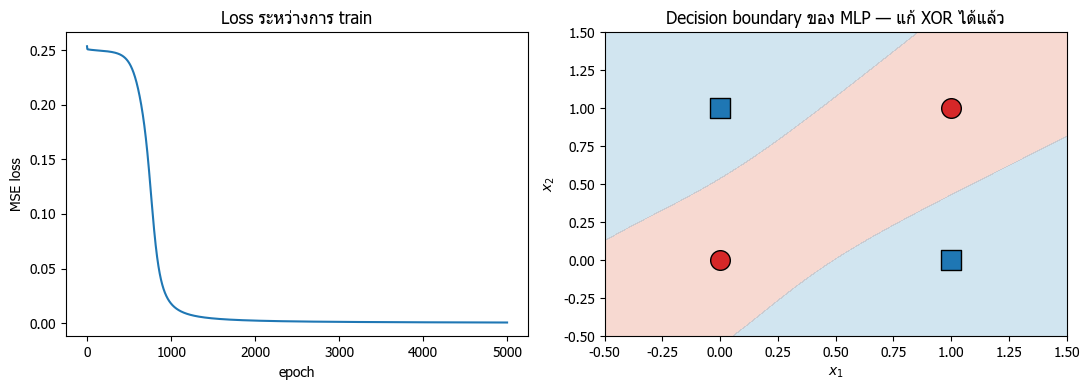

In [7]:
# ── ดู loss curve และ decision boundary ที่ MLP เรียนรู้ได้ ──
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

# (ซ้าย) loss ลดลงเรื่อย ๆ = โมเดลกำลังเรียนรู้
axes[0].plot(loss_history)
axes[0].set_xlabel("epoch"); axes[0].set_ylabel("MSE loss")
axes[0].set_title("Loss ระหว่างการ train")

# (ขวา) decision boundary โค้งงอได้แล้ว เพราะมี hidden layer
xx, yy = np.meshgrid(np.linspace(-0.5, 1.5, 200), np.linspace(-0.5, 1.5, 200))
grid = np.c_[xx.ravel(), yy.ravel()]
zz = sigmoid(sigmoid(grid @ W1 + b1) @ W2 + b2).reshape(xx.shape)   # forward ทั้ง grid
axes[1].contourf(xx, yy, zz, levels=[0, 0.5, 1], cmap="RdBu", alpha=0.3)
for xi, yi in zip(X, Y.ravel()):
    marker, color = ("s", "tab:blue") if yi == 1 else ("o", "tab:red")
    axes[1].scatter(*xi, marker=marker, c=color, s=200, edgecolors="k", zorder=3)
axes[1].set_title("Decision boundary ของ MLP — แก้ XOR ได้แล้ว")
axes[1].set_xlabel("$x_1$"); axes[1].set_ylabel("$x_2$")

plt.tight_layout()
plt.show()

---
## Part 4 — TensorFlow / Keras: เลิกเขียน backprop เอง

ทุกอย่างที่เขียนเองใน Part 2–3 มีคนเขียนไว้ให้แล้ว (พร้อม optimize และรันบน GPU ได้)
เทียบสิ่งที่เราเขียนเอง ↔ สิ่งที่ Keras ให้:

| ที่เราเขียนเองใน Part 2–3 | ใน Keras |
|---|---|
| `Z = X @ W + b` แล้วครอบ `sigmoid` | `layers.Dense(units, activation=...)` |
| สุ่มค่า weight เริ่มต้น | layer จัดการให้อัตโนมัติ |
| `backward()` — chain rule ทั้งหมด | **automatic differentiation** (TF หาอนุพันธ์ให้เอง) |
| `W -= lr * dW` | `optimizer` — และมีตัวฉลาดกว่า SGD เช่น **Adam** |
| คำนวณ MSE เอง | `loss="binary_crossentropy"` ฯลฯ |
| training loop ทั้งก้อน | `model.fit()` บรรทัดเดียว |

In [8]:
# ── XOR เดิมอีกครั้ง — คราวนี้ใช้ Keras ไม่กี่บรรทัด ──
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

tf.get_logger().setLevel("ERROR")     # ซ่อน warning ภายในของ TF
keras.utils.set_random_seed(42)       # fix seed ฝั่ง TF/Keras/NumPy พร้อมกัน

model = keras.Sequential([
    keras.Input(shape=(2,)),                 # input = เวกเตอร์ 2 ค่า (x1, x2)
    layers.Dense(8, activation="tanh"),      # hidden layer  ≡  sigmoid(X@W1+b1) ที่เราเขียนเอง
    layers.Dense(1, activation="sigmoid"),   # output layer  ≡  sigmoid(A1@W2+b2)
])

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.05),   # ตัว update weight (ฉลาดกว่า SGD เปล่า ๆ)
    loss="binary_crossentropy",                            # loss มาตรฐานของโจทย์ 0/1
    metrics=["accuracy"],
)

# .fit() = training loop ทั้งหมดของ Part 2–3 ในบรรทัดเดียว (forward → loss → backprop → update)
model.fit(X, Y, epochs=300, verbose=0)

print("ผลทำนาย XOR ด้วย Keras:")
for xi, pi in zip(X, model.predict(X, verbose=0)):
    print(f"  {xi.astype(int).tolist()} → {pi[0]:.4f}")

ผลทำนาย XOR ด้วย Keras:
  [0, 0] → 0.0002
  [0, 1] → 0.9996
  [1, 0] → 0.9995
  [1, 1] → 0.0007


### ตัวอย่างจริง: จำแนกตัวเลขลายมือ MNIST

XOR มีข้อมูลแค่ 4 แถว — ของจริงต้องใหญ่กว่านั้นมาก
**MNIST** คือชุดรูปลายมือเลข 0–9 ขนาด 28×28 pixel จำนวน 70,000 รูป ("Hello World" ของ deep learning)

โจทย์เปลี่ยนจาก binary (0/1) เป็น **multi-class (10 คลาส)** สิ่งที่ต้องเปลี่ยนตามมีแค่:
- output layer มี **10 neuron** + activation เป็น **softmax** (แปลงเป็นความน่าจะเป็นที่รวมกันได้ 1)
- loss เปลี่ยนเป็น **categorical cross-entropy**

In [9]:
# ── โหลดข้อมูล MNIST (รันครั้งแรกจะดาวน์โหลด ~11 MB) ──
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

# normalize ค่า pixel 0–255 → 0–1 (สเกล input เล็ก ๆ ช่วยให้ gradient descent เสถียร)
x_train, x_test = x_train / 255.0, x_test / 255.0
print("x_train:", x_train.shape, "| y_train:", y_train.shape)

mnist_model = keras.Sequential([
    keras.Input(shape=(28, 28)),
    layers.Flatten(),                          # คลี่รูป 28×28 → เวกเตอร์ 784 ค่า
    layers.Dense(128, activation="relu"),      # hidden layer (relu คือ activation มาตรฐานยุคนี้)
    layers.Dense(10, activation="softmax"),    # 10 คลาส → ความน่าจะเป็นของเลข 0–9
])
mnist_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",    # 'sparse' = label เป็นเลข 0–9 ตรง ๆ ไม่ต้องแปลง one-hot
    metrics=["accuracy"],
)

mnist_model.fit(x_train, y_train, epochs=3, batch_size=128, verbose=2)

# วัดผลบนข้อมูลที่โมเดล "ไม่เคยเห็น" — นี่คือตัวเลขที่เชื่อถือได้จริง
test_loss, test_acc = mnist_model.evaluate(x_test, y_test, verbose=0)
print(f"\nความแม่นยำบน test set (ข้อมูลที่ไม่เคยเห็น): {test_acc:.2%}")

x_train: (60000, 28, 28) | y_train: (60000,)


Epoch 1/3


469/469 - 4s - 8ms/step - accuracy: 0.9028 - loss: 0.3554


Epoch 2/3


469/469 - 2s - 5ms/step - accuracy: 0.9548 - loss: 0.1616


Epoch 3/3


469/469 - 2s - 5ms/step - accuracy: 0.9675 - loss: 0.1148



ความแม่นยำบน test set (ข้อมูลที่ไม่เคยเห็น): 96.58%


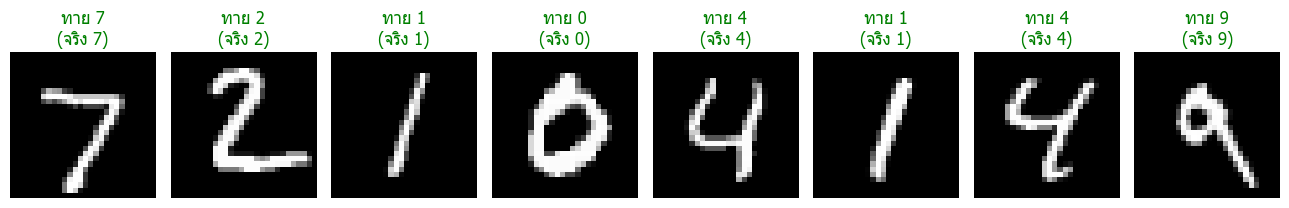

In [10]:
# ── ดูคำทำนายจริงพร้อมรูป ──
sample = x_test[:8]
pred_probs  = mnist_model.predict(sample, verbose=0)   # (8, 10) ความน่าจะเป็นของแต่ละคลาส
pred_labels = pred_probs.argmax(axis=1)                # เลือกคลาสที่ความน่าจะเป็นสูงสุด

fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for ax, img, pred, true in zip(axes, sample, pred_labels, y_test[:8]):
    ax.imshow(img, cmap="gray")
    ax.set_title(f"ทาย {pred}\n(จริง {true})", color="green" if pred == true else "red")
    ax.axis("off")
plt.tight_layout()
plt.show()

---
## Part 5 — Overfitting / Underfitting: ปัญหากลางของ ML ทั้งวงการ

เป้าหมายจริงของ ML ไม่ใช่ "ทำคะแนนดีบนข้อมูลที่ใช้ train" แต่คือ **ทำงานได้ดีกับข้อมูลใหม่ที่ไม่เคยเห็น** (generalization)

| อาการ | สาเหตุ | เปรียบเหมือนนักเรียนที่... |
|---|---|---|
| **Underfitting** | โมเดลเรียบง่ายเกินไป จับ pattern ไม่ได้ | ไม่ได้อ่านหนังสือเลย |
| พอดี | ความซับซ้อนเหมาะกับข้อมูล | เข้าใจเนื้อหาจริง ๆ |
| **Overfitting** | โมเดลซับซ้อนเกินไป **จำ**ข้อมูล train ได้หมดรวมถึง noise | ท่องข้อสอบเก่าได้ทุกข้อ แต่เจอข้อสอบใหม่แล้วทำไม่ได้ |

เห็นง่ายสุดด้วย polynomial regression: fit เส้นโค้งดีกรีต่าง ๆ บนข้อมูลชุดเดียวกัน

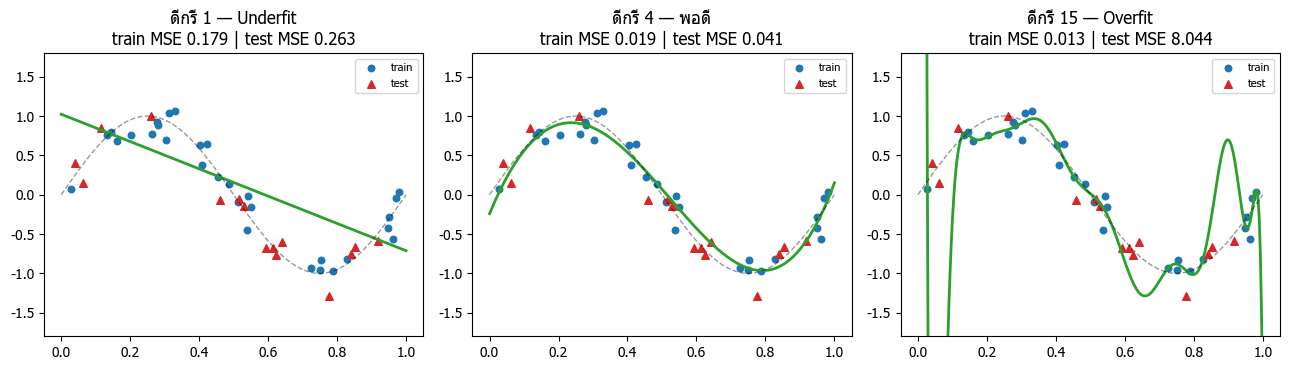

In [11]:
# ── Underfit vs พอดี vs Overfit ด้วย polynomial regression ──
from numpy.polynomial import Polynomial

rng_of = np.random.default_rng(1)
# ความจริงที่ซ่อนอยู่คือคลื่น sin + noise — แบ่งข้อมูลเป็น 2 กอง
x_all = rng_of.uniform(0, 1, 45)
y_all = np.sin(2 * np.pi * x_all) + rng_of.normal(0, 0.2, 45)
x_tr, y_tr = x_all[:30], y_all[:30]    # ชุด train — ใช้ fit โมเดล
x_te, y_te = x_all[30:], y_all[30:]    # ชุด test  — เก็บไว้ "สอบ" อย่างเดียว ห้ามใช้ fit

fig, axes = plt.subplots(1, 3, figsize=(13, 3.8))
xs = np.linspace(0, 1, 300)
for ax, degree in zip(axes, [1, 4, 15]):
    poly = Polynomial.fit(x_tr, y_tr, degree)        # fit polynomial ดีกรีที่กำหนด
    mse_tr = np.mean((poly(x_tr) - y_tr) ** 2)       # error บนข้อมูลที่ใช้ fit
    mse_te = np.mean((poly(x_te) - y_te) ** 2)       # error บนข้อมูลใหม่ ← ตัววัดที่แท้จริง

    ax.scatter(x_tr, y_tr, s=22, label="train")
    ax.scatter(x_te, y_te, s=30, marker="^", c="tab:red", label="test")
    ax.plot(xs, poly(xs), c="tab:green", lw=2)                     # สิ่งที่โมเดลเรียนได้
    ax.plot(xs, np.sin(2 * np.pi * xs), "k--", lw=1, alpha=0.4)    # ความจริงที่ซ่อนอยู่
    ax.set_ylim(-1.8, 1.8); ax.legend(fontsize=8)
    label = {1: "Underfit", 4: "พอดี", 15: "Overfit"}[degree]
    ax.set_title(f"ดีกรี {degree} — {label}\ntrain MSE {mse_tr:.3f} | test MSE {mse_te:.3f}")
plt.tight_layout()
plt.show()
# ดีกรี 1:  ง่ายเกินไป จับคลื่นไม่ได้เลย (error สูงทั้งสองชุด)
# ดีกรี 15: train MSE ต่ำสุด แต่ test MSE ระเบิด — มันจำ noise ของชุด train มาทั้งดุ้น

### จับ overfitting ใน neural network — แบ่งข้อมูลไว้ "สอบ" เสมอ

polynomial ยังวาดดูได้ด้วยตา แต่ neural network มิติสูงเกินกว่าจะวาด วิธีมาตรฐานคือ
**กันข้อมูลส่วนหนึ่งเป็น validation set** ที่ไม่ถูกใช้ train แล้วเฝ้าดู loss ทั้งสองเส้นไปพร้อมกัน:

- train loss ลด + val loss ลด → กำลังเรียนรู้จริง ✓
- train loss ลดต่อไปเรื่อย ๆ แต่ val loss **เด้งขึ้น** → เริ่ม "ท่องจำ" แล้ว (overfit)

ลองจงใจสร้างสถานการณ์: โมเดลใหญ่ (~270k parameters) แต่ให้ข้อมูลแค่ 1,000 รูป เทียบกับให้ 10,000 รูป

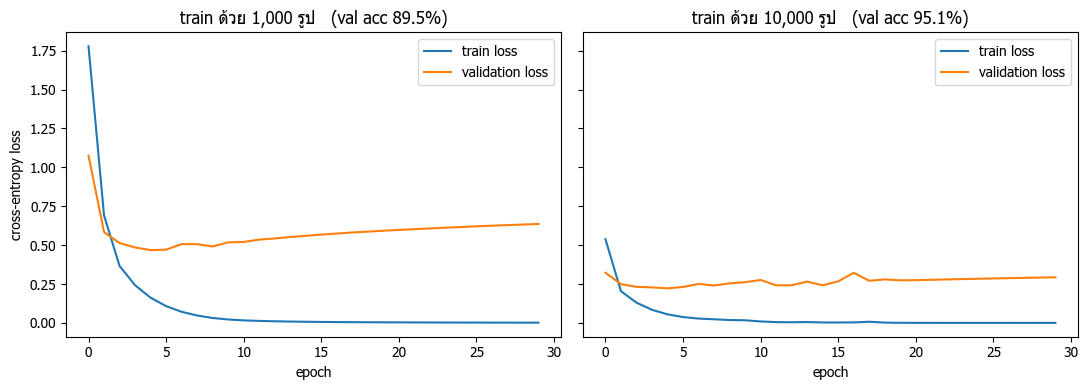

In [12]:
# ── ทดลอง: โมเดลใหญ่ + ข้อมูลน้อย = overfit / เพิ่มข้อมูลแล้วดีขึ้นแค่ไหน ──

def make_big_model():
    m = keras.Sequential([
        keras.Input(shape=(28, 28)), layers.Flatten(),
        layers.Dense(256, activation="relu"),
        layers.Dense(256, activation="relu"),
        layers.Dense(10, activation="softmax"),
    ])
    m.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
    return m

histories = {}
for n in (1_000, 10_000):                # เทียบ: ข้อมูลน้อย vs เพิ่มข้อมูล 10 เท่า (โมเดลเดียวกัน)
    keras.utils.set_random_seed(0)
    histories[n] = make_big_model().fit(
        x_train[:n], y_train[:n],
        epochs=30, batch_size=64,
        validation_split=0.2,            # กัน 20% ไว้เป็น validation — ส่วนนี้ไม่ถูกใช้ train
        verbose=0,
    )

fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, (n, h) in zip(axes, histories.items()):
    ax.plot(h.history["loss"], label="train loss")
    ax.plot(h.history["val_loss"], label="validation loss")
    ax.set_title(f"train ด้วย {n:,} รูป   (val acc {h.history['val_accuracy'][-1]:.1%})")
    ax.set_xlabel("epoch"); ax.legend()
axes[0].set_ylabel("cross-entropy loss")
plt.tight_layout()
plt.show()
# ซ้าย (1,000 รูป):  train loss ดิ่งเกือบ 0 แต่ val loss เด้งขึ้นตั้งแต่ epoch แรก ๆ = ท่องจำชัด ๆ
# ขวา (10,000 รูป): ช่องว่าง train/val แคบลงมาก และ val acc กระโดดขึ้น — ข้อมูลคือยาแรงสุด

**สรุปวิธีลด overfitting** (เรียงตามที่มักได้ผล):

1. **เพิ่มข้อมูล** — ยาแรงสุด อย่างที่เห็นในกราฟขวา
2. **Early stopping** — หยุด train ตรงจุดที่ val loss เริ่มเด้งขึ้น:
   `model.fit(..., callbacks=[keras.callbacks.EarlyStopping(patience=3, restore_best_weights=True)])`
3. **Dropout** — สุ่มปิด neuron ระหว่าง train เพื่อไม่ให้พึ่งพา neuron ตัวใดตัวหนึ่งมากเกินไป: `layers.Dropout(0.5)`
4. **ลดขนาดโมเดล / L2 regularization** — จำกัด "ความจุ" ไม่ให้พอที่จะท่องจำ

> นิสัยที่ควรติดตัว: เห็นตัวเลข accuracy ที่ไหน ให้ถามก่อนว่า **"วัดบนข้อมูลที่โมเดลเคยเห็นหรือเปล่า?"**
> — นี่คือเหตุผลที่ Part 4 เราวัดผล MNIST บน test set ที่แยกไว้ต่างหาก

---
## Part 6 — CNN: สถาปัตยกรรมที่ "เข้าใจ" รูปภาพ

Part 4 เราคลี่รูป 28×28 เป็นเวกเตอร์ 784 ค่าก่อนเข้า Dense — ซึ่งทิ้งข้อมูลสำคัญไปเลยว่า **pixel ไหนอยู่ติดกับ pixel ไหน**

**Convolution** แก้ตรงนี้ด้วย **filter** ขนาดเล็ก (เช่น 3×3) ที่เลื่อนสแกนไปทั่วทั้งรูป:

- filter 1 ตัว = ตัวตรวจจับ pattern 1 แบบ (ขอบตั้ง เส้นโค้ง มุม ฯลฯ) — ค่าใน filter **เรียนรู้เอง**ผ่าน backprop เหมือน weight ทุกตัวที่ผ่านมา
- pattern อยู่ตรงไหนของรูปก็ตรวจเจอ และใช้ weight ชุดเดียวกันทั้งรูป → parameter น้อยกว่า Dense มาก
- **MaxPooling** ย่อรูปลงครึ่งโดยเก็บเฉพาะสัญญาณที่เด่นสุด → ชั้นถัดไปมองเห็น "ภาพรวม" ที่กว้างขึ้น

โครงสร้างคลาสสิก: `Conv → Pool → Conv → Pool → Flatten → Dense`
ชั้นยิ่งลึก filter ยิ่งจับของซับซ้อนขึ้น (ขอบ → ลายเส้น → ชิ้นส่วนของตัวเลข)

> ประเด็นที่ใหญ่กว่า MNIST: **เลือกสถาปัตยกรรมให้เข้ากับโครงสร้างข้อมูล** —
> รูปภาพใช้ convolution, ข้อมูลลำดับ/ภาษาใช้ attention (Part 7 ที่กำลังจะถึง)

In [13]:
# ── CNN บน MNIST ──
# Conv2D ต้องการ input 3 มิติ (สูง, กว้าง, channel) — รูปขาวดำมี 1 channel
x_train_img = x_train[..., np.newaxis]    # (60000, 28, 28, 1)
x_test_img  = x_test[..., np.newaxis]

keras.utils.set_random_seed(42)
cnn = keras.Sequential([
    keras.Input(shape=(28, 28, 1)),
    layers.Conv2D(32, 3, activation="relu"),   # filter 3×3 จำนวน 32 ตัว → จับ pattern พื้นฐาน 32 แบบ
    layers.MaxPooling2D(),                     # ย่อครึ่ง: 26×26 → 13×13
    layers.Conv2D(64, 3, activation="relu"),   # ชั้นลึกขึ้น จับ pattern ที่ประกอบจากของชั้นแรก
    layers.MaxPooling2D(),                     # 11×11 → 5×5
    layers.Flatten(),                          # ตอนนี้ค่อยคลี่ — เพราะสกัด feature เชิงพื้นที่มาแล้ว
    layers.Dense(10, activation="softmax"),
])
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
cnn.fit(x_train_img, y_train, epochs=3, batch_size=128, verbose=2)

cnn_loss, cnn_acc = cnn.evaluate(x_test_img, y_test, verbose=0)
n_wrong = round((1 - cnn_acc) * len(y_test))
print(f"\nDense ธรรมดา (Part 4): 96.58%  →  CNN: {cnn_acc:.2%}")
print(f"จำนวนรูปที่ทายผิดจาก 10,000: ~342 → {n_wrong} (ลดลงราวครึ่งหนึ่ง ด้วยเวลา train พอ ๆ กัน)")

Epoch 1/3


469/469 - 11s - 23ms/step - accuracy: 0.9236 - loss: 0.2736


Epoch 2/3


469/469 - 12s - 27ms/step - accuracy: 0.9775 - loss: 0.0741


Epoch 3/3


469/469 - 19s - 41ms/step - accuracy: 0.9834 - loss: 0.0546



Dense ธรรมดา (Part 4): 96.58%  →  CNN: 98.35%
จำนวนรูปที่ทายผิดจาก 10,000: ~342 → 165 (ลดลงราวครึ่งหนึ่ง ด้วยเวลา train พอ ๆ กัน)


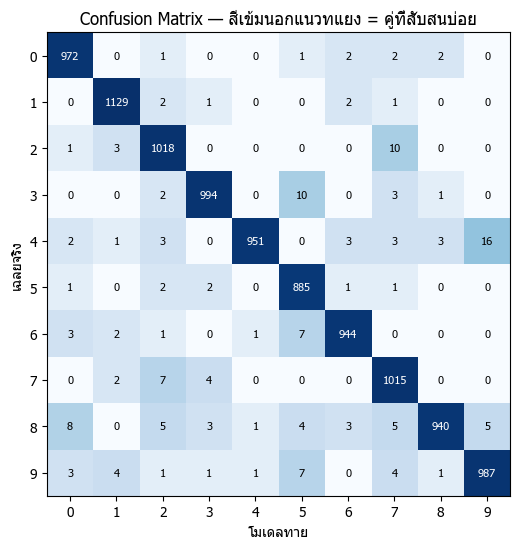

สับสนบ่อยสุด: เฉลย 4 แต่ทายเป็น 9  (16 รูป)


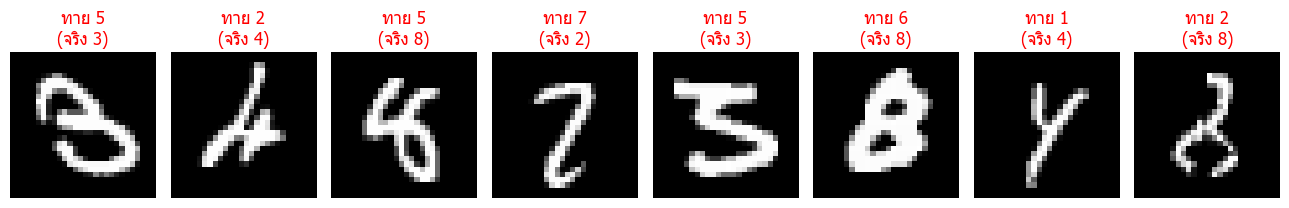

In [14]:
# ── มองลึกกว่า accuracy: confusion matrix ──
pred_test = cnn.predict(x_test_img, verbose=0).argmax(axis=1)

# confusion[i, j] = จำนวนรูปที่เฉลยคือ i แต่โมเดลทายเป็น j  (แนวทแยง = ทายถูก)
confusion = np.zeros((10, 10), dtype=int)
for true, pred in zip(y_test, pred_test):
    confusion[true, pred] += 1

fig, ax = plt.subplots(figsize=(6.2, 5.6))
ax.imshow(np.log1p(confusion), cmap="Blues")    # log scale — ให้ช่องที่ผิดน้อย ๆ ยังมองเห็นสี
ax.set_xticks(range(10)); ax.set_yticks(range(10))
ax.set_xlabel("โมเดลทาย"); ax.set_ylabel("เฉลยจริง")
ax.set_title("Confusion Matrix — สีเข้มนอกแนวทแยง = คู่ที่สับสนบ่อย")
for i in range(10):
    for j in range(10):
        ax.text(j, i, confusion[i, j], ha="center", va="center", fontsize=8,
                color="white" if i == j else "black")
plt.tight_layout()
plt.show()

# คู่ที่โมเดลสับสนบ่อยที่สุด
off_diag = confusion - np.diag(np.diag(confusion))
i, j = np.unravel_index(off_diag.argmax(), off_diag.shape)
print(f"สับสนบ่อยสุด: เฉลย {i} แต่ทายเป็น {j}  ({off_diag[i, j]} รูป)")

# ── ดูรูปที่ทายผิด — ส่วนใหญ่เป็นลายมือที่คนยังต้องเพ่ง ──
wrong_idx = np.where(pred_test != y_test)[0][:8]
fig, axes = plt.subplots(1, 8, figsize=(13, 2.2))
for ax, idx in zip(axes, wrong_idx):
    ax.imshow(x_test[idx], cmap="gray")
    ax.set_title(f"ทาย {pred_test[idx]}\n(จริง {y_test[idx]})", color="red")
    ax.axis("off")
plt.tight_layout()
plt.show()

### ทำไม accuracy อย่างเดียวไม่พอ

MNIST มี 10 คลาสจำนวนพอ ๆ กัน accuracy จึงพอใช้ได้ แต่ถ้าข้อมูล**ไม่สมดุล** accuracy จะหลอกตาทันที
— ตัวอย่างคลาสสิก: ตรวจคัดกรองโรคที่พบในประชากรแค่ 1%

In [15]:
# ── accuracy หลอกตาเมื่อข้อมูลไม่สมดุล ──
N = 10_000
y_true = np.zeros(N, dtype=int)
y_true[:100] = 1                      # ผู้ป่วยจริง 1% (100 คนจาก 10,000)

y_lazy = np.zeros(N, dtype=int)       # "โมเดลขี้เกียจ": ทายว่าไม่ป่วย...ทุกคน

accuracy = np.mean(y_lazy == y_true)
tp = np.sum((y_lazy == 1) & (y_true == 1))       # ป่วยจริงและตรวจเจอ (true positive)
recall = tp / np.sum(y_true == 1)                # เจอผู้ป่วยกี่ส่วนจากผู้ป่วยทั้งหมด

print(f"accuracy = {accuracy:.1%}   ← ดูดีมาก!")
print(f"recall   = {recall:.1%}     ← แต่ตรวจไม่เจอผู้ป่วยแม้แต่คนเดียว")

# บทเรียน: เลือก metric ให้ตรงกับ "ความเสียหายจริง" ของงาน
#   recall    สำคัญเมื่อพลาดของจริงแล้วแพง   (คัดกรองโรค — ปล่อยผู้ป่วยหลุดไม่ได้)
#   precision สำคัญเมื่อเตือนผิดแล้วแพง       (กรอง spam — เผลอกรองเมลสำคัญทิ้งไม่ได้)

accuracy = 99.0%   ← ดูดีมาก!
recall   = 0.0%     ← แต่ตรวจไม่เจอผู้ป่วยแม้แต่คนเดียว


---
## Part 7 — Attention Mechanism: หัวใจของ Transformer

โมเดลใน Part 1–6 รับ input ขนาดคงที่ แต่ภาษาเป็น **ลำดับ (sequence)** ที่ยาวไม่เท่ากัน
และความหมายของคำขึ้นกับ**บริบท** — "ตา" ใน *"ตาพร่ามัว"* กับ *"ตากับยาย"* คนละความหมายกันเลย

**Self-attention** แก้ปัญหานี้ด้วยไอเดียเดียว:
ให้ **token แต่ละตัว "มอง" token อื่นทั้งประโยค แล้วดูดข้อมูลจากตัวที่เกี่ยวข้องมาปรับความหมายของตัวเอง**

แต่ละ token สร้างเวกเตอร์ 3 ตัวจาก embedding ของมัน (อุปมาเหมือนระบบสืบค้น):

| เวกเตอร์ | คำนวณจาก | เปรียบเหมือน |
|---|---|---|
| **Q**uery | $Q = XW_Q$ | "ฉันกำลัง**ตามหา**ข้อมูลแบบไหน" |
| **K**ey | $K = XW_K$ | "**ป้ายชื่อ**ของฉัน — ฉันมีข้อมูลประเภทไหนให้" |
| **V**alue | $V = XW_V$ | "**เนื้อหาจริง**ที่ฉันจะส่งให้คนที่สนใจฉัน" |

สมการเดียวที่ต้องจำ (จาก paper *Attention Is All You Need*, 2017):

$$\text{Attention}(Q,K,V) = \text{softmax}\!\left(\frac{QK^\top}{\sqrt{d_k}}\right)V$$

อ่านเป็นภาษาคน: *"เอา query ของแต่ละ token ไปเทียบกับ key ของทุก token (dot product = คะแนนความเข้ากัน)
→ แปลงเป็นสัดส่วนความสนใจด้วย softmax → ใช้สัดส่วนนั้นถัวเฉลี่ย value ของทุก token"*

มาเขียนทีละขั้นด้วย NumPy ล้วน ๆ:

In [16]:
# ── เตรียมตัวอย่าง: ประโยค 4 token ──
np.random.seed(7)

tokens = ["I", "love", "machine", "learning"]
T = len(tokens)      # ความยาว sequence = 4
d_model = 8          # ขนาดเวกเตอร์ embedding ของแต่ละ token
d_k = 8              # ขนาดเวกเตอร์ Q, K, V

# ใน LLM จริง embedding มาจากตารางที่ "เรียนรู้" มาแล้ว — ที่นี่สุ่มเพื่อสาธิตกลไกการคำนวณ
X_emb = np.random.randn(T, d_model)            # (4, 8) — แถวละ 1 token

# weight 3 ก้อน (ของจริงก็เรียนรู้ผ่าน backprop เหมือน W ทุกตัวใน Part 2–3)
W_Q = np.random.randn(d_model, d_k) / np.sqrt(d_model)
W_K = np.random.randn(d_model, d_k) / np.sqrt(d_model)
W_V = np.random.randn(d_model, d_k) / np.sqrt(d_model)

# แต่ละ token แปลงร่างเป็น 3 บทบาท
Q = X_emb @ W_Q     # (4, 8)  "สิ่งที่ฉันตามหา"
K = X_emb @ W_K     # (4, 8)  "ป้ายชื่อของฉัน"
V = X_emb @ W_V     # (4, 8)  "เนื้อหาที่ฉันให้ได้"
print("shape:  X", X_emb.shape, "  Q", Q.shape, "  K", K.shape, "  V", V.shape)

shape:  X (4, 8)   Q (4, 8)   K (4, 8)   V (4, 8)


In [17]:
# ── Scaled Dot-Product Attention ทีละขั้น ──

def softmax(x, axis=-1):
    """softmax แบบ numerically stable (ลบ max ก่อน กัน overflow ของ exp)"""
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

# ขั้น 1: คะแนนความเข้ากัน — dot product ของ query ทุกตัว กับ key ทุกตัว
#         scores[i, j] = "token i ควรสนใจ token j แค่ไหน" (ยังเป็นคะแนนดิบ)
scores = Q @ K.T                          # (4, 4)

# ขั้น 2: หารด้วย √d_k — ถ้า d_k ใหญ่ dot product จะแกว่งแรง ทำให้ softmax "อิ่มตัว"
#         (ความสนใจพุ่งไปตัวเดียว, gradient เกือบศูนย์ → เรียนรู้ไม่ได้) จึงต้อง scale ลง
scores = scores / np.sqrt(d_k)

# ขั้น 3: softmax รายแถว → แต่ละแถวกลายเป็น "สัดส่วนความสนใจ" ที่รวมกันได้ 1
attn_weights = softmax(scores, axis=-1)   # (4, 4)

# ขั้น 4: ถัวเฉลี่ย value ตามสัดส่วนความสนใจ
#         → ได้เวกเตอร์ใหม่ของแต่ละ token ที่ "ผสมบริบทจากทั้งประโยค" แล้ว
attn_output = attn_weights @ V            # (4, 8)

print("attention weights (แต่ละแถวรวมกัน = 1):\n")
for tok, row in zip(tokens, attn_weights):
    detail = "   ".join(f"{t}: {w:.2f}" for t, w in zip(tokens, row))
    print(f"  '{tok}' สนใจ →   {detail}")
print("\nattn_output shape:", attn_output.shape, " (1 เวกเตอร์ต่อ 1 token เท่าเดิม แต่รับรู้บริบทแล้ว)")

attention weights (แต่ละแถวรวมกัน = 1):

  'I' สนใจ →   I: 0.22   love: 0.12   machine: 0.19   learning: 0.47
  'love' สนใจ →   I: 0.38   love: 0.14   machine: 0.15   learning: 0.33
  'machine' สนใจ →   I: 0.36   love: 0.32   machine: 0.18   learning: 0.13
  'learning' สนใจ →   I: 0.37   love: 0.49   machine: 0.08   learning: 0.06

attn_output shape: (4, 8)  (1 เวกเตอร์ต่อ 1 token เท่าเดิม แต่รับรู้บริบทแล้ว)


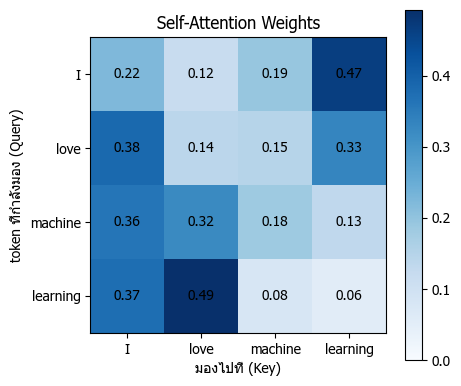

In [18]:
# ── วาด attention matrix เป็น heatmap ──
fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(attn_weights, cmap="Blues", vmin=0)
ax.set_xticks(range(T), tokens)
ax.set_yticks(range(T), tokens)
ax.set_xlabel("มองไปที่ (Key)")
ax.set_ylabel("token ที่กำลังมอง (Query)")
ax.set_title("Self-Attention Weights")
for i in range(T):                        # เขียนตัวเลขทับลงในแต่ละช่อง
    for j in range(T):
        ax.text(j, i, f"{attn_weights[i,j]:.2f}", ha="center", va="center",
                color="white" if attn_weights[i,j] > 0.5 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()

### Causal Mask — เคล็ดลับที่เปลี่ยน Transformer ให้เป็น "LLM"

LLM ถูก train ให้**ทำนาย token ถัดไป** ดังนั้นตอน train ห้ามให้ token "แอบดูอนาคต" เด็ดขาด
(ไม่งั้นโจทย์ง่ายเกิน โมเดลแค่ลอกคำตอบที่อยู่ข้างหน้า)

วิธีทำง่ายมาก: ก่อนเข้า softmax เอา $-\infty$ ไปทับคะแนนของตำแหน่งที่อยู่ "ข้างหน้า"
เพราะ $e^{-\infty} = 0$ → softmax ให้ความสนใจตำแหน่งนั้นเป็นศูนย์พอดี

mask (True = ห้ามมอง):
[[0 1 1 1]
 [0 0 1 1]
 [0 0 0 1]
 [0 0 0 0]] 



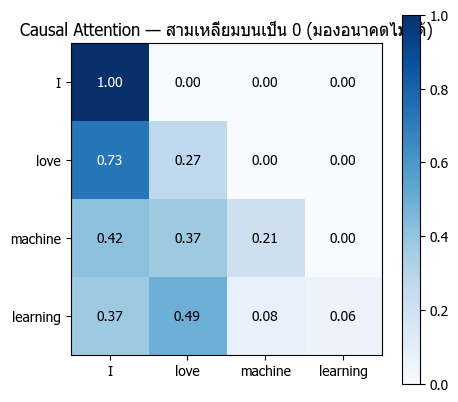

In [19]:
# ── Causal (masked) self-attention ──

# สร้าง mask สามเหลี่ยมบน: ช่อง (i, j) ที่ j > i คือ "อนาคต" ของ token i → ต้องปิด
causal_mask = np.triu(np.ones((T, T)), k=1).astype(bool)
print("mask (True = ห้ามมอง):")
print(causal_mask.astype(int), "\n")

# ทับคะแนนของตำแหน่งอนาคตด้วย -inf "ก่อน" เข้า softmax
masked_scores  = np.where(causal_mask, -np.inf, (Q @ K.T) / np.sqrt(d_k))
causal_weights = softmax(masked_scores, axis=-1)

fig, ax = plt.subplots(figsize=(4.8, 4.2))
im = ax.imshow(causal_weights, cmap="Blues", vmin=0)
ax.set_xticks(range(T), tokens)
ax.set_yticks(range(T), tokens)
ax.set_title("Causal Attention — สามเหลี่ยมบนเป็น 0 (มองอนาคตไม่ได้)")
for i in range(T):
    for j in range(T):
        ax.text(j, i, f"{causal_weights[i,j]:.2f}", ha="center", va="center",
                color="white" if causal_weights[i,j] > 0.5 else "black")
plt.colorbar(im)
plt.tight_layout()
plt.show()
# สังเกต: token แรก ("I") มองได้แค่ตัวเอง → ความสนใจ = 1.00 เต็ม

### Multi-Head Attention — มองหลายมุมพร้อมกัน

แทนที่จะมี attention ชุดเดียว Transformer แบ่งเป็นหลาย "หัว" (head)
แต่ละหัวมี $W_Q, W_K, W_V$ ของตัวเอง จึง**จับความสัมพันธ์คนละแบบ**ได้พร้อมกัน
(เช่น หัวหนึ่งจับไวยากรณ์ อีกหัวจับว่าสรรพนามอ้างถึงใคร ฯลฯ)
เสร็จแล้วต่อ (concatenate) ผลของทุกหัวกลับเป็นเวกเตอร์เดียว แล้ว project อีกครั้ง

In [20]:
# ── Multi-Head Attention เขียนเองด้วย NumPy ──

def attention(Q, K, V, causal=False):
    """scaled dot-product attention — สมการเดียวจาก paper"""
    d = Q.shape[-1]
    scores = (Q @ K.swapaxes(-2, -1)) / np.sqrt(d)
    if causal:                                       # ปิดการมองอนาคต (สำหรับ LLM)
        n = scores.shape[-1]
        scores = np.where(np.triu(np.ones((n, n)), k=1).astype(bool), -np.inf, scores)
    return softmax(scores, axis=-1) @ V

def multi_head_attention(X, n_heads=2, causal=True, seed=0):
    T, d_model = X.shape
    d_head = d_model // n_heads          # แบ่งมิติให้แต่ละหัวเท่า ๆ กัน
    rng = np.random.default_rng(seed)

    head_outputs = []
    for h in range(n_heads):
        # แต่ละหัวมี projection ของตัวเอง → มองข้อมูล "คนละมุม"
        Wq = rng.standard_normal((d_model, d_head)) / np.sqrt(d_model)
        Wk = rng.standard_normal((d_model, d_head)) / np.sqrt(d_model)
        Wv = rng.standard_normal((d_model, d_head)) / np.sqrt(d_model)
        head_outputs.append(attention(X @ Wq, X @ Wk, X @ Wv, causal=causal))

    concat = np.concatenate(head_outputs, axis=-1)   # (T, d_model) — ต่อผลทุกหัวกลับ
    W_O = rng.standard_normal((d_model, d_model)) / np.sqrt(d_model)
    return concat @ W_O                              # output projection สุดท้าย

mha_out = multi_head_attention(X_emb, n_heads=2)
print("multi-head output:", mha_out.shape, " (shape เท่า input เป๊ะ → วางซ้อนกันกี่ชั้นก็ได้)")

multi-head output: (4, 8)  (shape เท่า input เป๊ะ → วางซ้อนกันกี่ชั้นก็ได้)


### Positional Encoding — บอกโมเดลว่า token อยู่ตำแหน่งไหน

สังเกตว่าสมการ attention **ไม่สนลำดับเลย** (สลับ token แล้วผลก็แค่สลับตาม)
แต่ภาษานั้นลำดับสำคัญมาก — *"หมากัดคน"* ≠ *"คนกัดหมา"*

วิธีแก้: **บวกเวกเตอร์ประจำตำแหน่ง**เข้ากับ embedding ก่อนเข้า attention
ฉบับดั้งเดิมใช้คลื่น sin/cos หลายความถี่ — แต่ละตำแหน่งได้ "ลายนิ้วมือ" ที่ไม่ซ้ำกัน:

$$PE_{(pos,\,2i)} = \sin\!\frac{pos}{10000^{2i/d}} \qquad PE_{(pos,\,2i+1)} = \cos\!\frac{pos}{10000^{2i/d}}$$

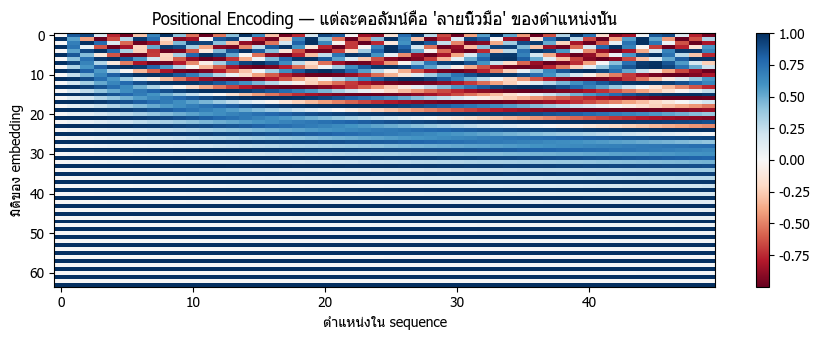

In [21]:
# ── Sinusoidal Positional Encoding ──

def positional_encoding(seq_len, d_model):
    pos = np.arange(seq_len)[:, None]        # (seq_len, 1)  ตำแหน่ง 0,1,2,...
    i   = np.arange(d_model)[None, :]        # (1, d_model)  index ของแต่ละมิติ
    # ความถี่ลดหลั่นกัน: มิติแรกเปลี่ยนเร็ว มิติหลังเปลี่ยนช้า (เหมือนเข็มวินาที/นาที/ชั่วโมง)
    angle = pos / np.power(10000, (2 * (i // 2)) / d_model)
    pe = np.zeros((seq_len, d_model))
    pe[:, 0::2] = np.sin(angle[:, 0::2])     # มิติเลขคู่ → sin
    pe[:, 1::2] = np.cos(angle[:, 1::2])     # มิติเลขคี่ → cos
    return pe

pe = positional_encoding(seq_len=50, d_model=64)

plt.figure(figsize=(9, 3.5))
plt.imshow(pe.T, cmap="RdBu", aspect="auto")
plt.xlabel("ตำแหน่งใน sequence")
plt.ylabel("มิติของ embedding")
plt.title("Positional Encoding — แต่ละคอลัมน์คือ 'ลายนิ้วมือ' ของตำแหน่งนั้น")
plt.colorbar()
plt.tight_layout()
plt.show()

# วิธีใช้งานจริง: บวกเข้ากับ embedding ตรง ๆ ก่อนเข้า transformer
#   X_input = token_embedding + positional_encoding

### ประกอบร่าง: Transformer Block

Transformer 1 block ของจริง = attention + ส่วนประกอบอีกนิดเดียว แล้วเอาไป**วางซ้อนกันหลายสิบชั้น**:

```
input ──→ [ Multi-Head Attention ] ──(+)── LayerNorm ──→ [ Feed-Forward ] ──(+)── LayerNorm ──→ output
   └──────── residual ────────────────┘            └────── residual ──────────┘
```

- **Feed-Forward** = MLP แบบเดียวกับ Part 2 เป๊ะ ๆ (Dense 2 ชั้น) ทำงานแยกทีละ token
- **Residual connection** (`x + f(x)`) = "ทางลัด" ให้ gradient ไหลย้อนผ่านโมเดลลึก ๆ ได้โดยไม่จางหาย
- **LayerNorm** = ปรับ scale ของค่าให้นิ่ง ทำให้ train ง่ายขึ้น

GPT, Claude, Llama, Gemini = block หน้าตาแบบนี้ซ้อนกัน N ชั้น + tokenizer + ข้อมูลกับ GPU มหาศาล
ใน Part 8 เราจะประกอบทุกชิ้นเป็น LLM จิ๋วที่ generate ข้อความได้จริง

---
## Part 8 — Mini LLM: GPT จิ๋วระดับตัวอักษร (Char-Level)

ประกอบทุกอย่างที่เรียนมาเป็น **language model ที่ train แล้ว generate ข้อความได้จริง**

pipeline ของ LLM ทุกตัว (รวมถึงตัวที่คุณกำลังคุยด้วยตอนนี้) เหมือนกันหมด:

1. **Tokenize** — ตัดข้อความเป็น token แทนด้วยตัวเลข (ของเราใช้ 1 ตัวอักษร = 1 token เพื่อความง่าย, ของจริงใช้ subword/BPE)
2. **Embedding** — ตัวเลข → เวกเตอร์ + บวกข้อมูลตำแหน่ง
3. **Transformer blocks** — causal self-attention + feed-forward ซ้อนกันหลายชั้น
4. **Output head** — เวกเตอร์ตำแหน่งสุดท้าย → คะแนน (logits) ของ token ถัดไปทุกตัวใน vocab
5. **Training** — โจทย์เดียวล้วน ๆ: *ทาย token ถัดไป* (next-token prediction)
6. **Generation** — ทาย 1 token, ต่อท้าย, แล้วทายต่อ... วนไปเรื่อย ๆ (autoregressive)

In [22]:
# ── ขั้น 1: corpus เล็ก ๆ + tokenizer ระดับตัวอักษร ──

# ข้อความที่มีโครงสร้างซ้ำ ๆ — เล็กพอให้ train บน CPU ได้ในไม่กี่สิบวินาที
corpus = (
    "the cat sat on the mat. the dog sat on the log. "
    "the cat saw the dog and ran to the mat. "
    "the dog saw the cat and ran to the log. "
    "the cat and the dog sat on the mat. "
) * 5

# vocab = ตัวอักษรทุกตัวที่พบใน corpus (LLM จริงใช้ BPE ได้ vocab ~100,000 token)
vocab = sorted(set(corpus))
vocab_size = len(vocab)
char2id = {c: i for i, c in enumerate(vocab)}   # encode: ตัวอักษร → ตัวเลข
id2char = {i: c for i, c in enumerate(vocab)}   # decode: ตัวเลข → ตัวอักษร

data = np.array([char2id[c] for c in corpus], dtype=np.int32)
print(f"corpus ยาว {len(corpus):,} ตัวอักษร | vocab {vocab_size} ตัว: {''.join(vocab)!r}")
print("ตัวอย่าง encode:", repr(corpus[:12]), "→", data[:12].tolist())

corpus ยาว 820 ตัวอักษร | vocab 16 ตัว: ' .acdeghlmnorstw'
ตัวอย่าง encode: 'the cat sat ' → [14, 7, 5, 0, 3, 2, 14, 0, 13, 2, 14, 0]


In [23]:
# ── ขั้น 2: สร้างคู่ (input → target) สำหรับโจทย์ "ทายตัวอักษรถัดไป" ──
SEQ_LEN = 48   # context window ฉบับจิ๋ว — โมเดลมองย้อนหลังได้ไกลสุดกี่ตัวอักษร

# เลื่อนหน้าต่างทีละ 1 ตัวอักษร:  target = input ที่ขยับไปข้างหน้า 1 ตำแหน่ง
# ทุกตำแหน่ง i ใน input โมเดลต้องทายว่าตัวอักษรถัดไปคืออะไร → ได้ 48 โจทย์ย่อยต่อ 1 ตัวอย่าง
inputs  = np.array([data[i   : i+SEQ_LEN  ] for i in range(len(data) - SEQ_LEN - 1)])
targets = np.array([data[i+1 : i+SEQ_LEN+1] for i in range(len(data) - SEQ_LEN - 1)])
print("inputs:", inputs.shape, "  targets:", targets.shape)

# ดูตัวอย่าง 1 คู่ — สังเกตว่า y คือ x ที่เลื่อนซ้าย 1 ตัว
print("x:", "".join(id2char[i] for i in inputs[0]))
print("y:", "".join(id2char[i] for i in targets[0]))

inputs: (771, 48)   targets: (771, 48)
x: the cat sat on the mat. the dog sat on the log. 
y: he cat sat on the mat. the dog sat on the log. t


In [24]:
# ── ขั้น 3: ประกอบโมเดล GPT จิ๋ว ──
D_MODEL  = 64    # ขนาดเวกเตอร์ของแต่ละ token   (GPT-3: 12288)
N_HEADS  = 4     # จำนวนหัว attention            (GPT-3: 96)
FF_DIM   = 128   # ขนาด hidden ของ feed-forward
N_BLOCKS = 2     # จำนวน transformer block        (GPT-3: 96)

class TokenAndPositionEmbedding(layers.Layer):
    """ขั้น embedding: รวมข้อมูล 'token นี้คือตัวอะไร' + 'อยู่ตำแหน่งไหน'"""
    def __init__(self, maxlen, vocab_size, d_model):
        super().__init__()
        self.token_emb = layers.Embedding(vocab_size, d_model)  # ตาราง embedding ของ token (เรียนรู้ได้)
        self.pos_emb   = layers.Embedding(maxlen, d_model)      # ตาราง embedding ของตำแหน่ง (แบบเรียนรู้ได้
                                                                # — ทำหน้าที่เดียวกับ sin/cos ใน Part 7)
    def call(self, x):
        positions = tf.range(tf.shape(x)[-1])                   # [0, 1, 2, ..., ความยาว seq]
        return self.token_emb(x) + self.pos_emb(positions)      # บวกกันตรง ๆ

class TransformerBlock(layers.Layer):
    """1 block = causal self-attention + feed-forward พร้อม residual + LayerNorm (ตามผัง Part 7)"""
    def __init__(self, d_model, n_heads, ff_dim):
        super().__init__()
        self.attn = layers.MultiHeadAttention(num_heads=n_heads,
                                              key_dim=d_model // n_heads)
        # feed-forward = MLP 2 ชั้น แบบเดียวกับ Part 2 (ทำงานแยกทีละ token)
        self.ffn = keras.Sequential([
            layers.Dense(ff_dim, activation="relu"),
            layers.Dense(d_model),
        ])
        self.norm1 = layers.LayerNormalization()
        self.norm2 = layers.LayerNormalization()

    def call(self, x):
        # use_causal_mask=True = mask สามเหลี่ยมแบบเดียวกับที่เขียนเองใน Part 7
        attn_out = self.attn(x, x, use_causal_mask=True)
        x = self.norm1(x + attn_out)        # residual connection + LayerNorm
        ffn_out = self.ffn(x)
        return self.norm2(x + ffn_out)      # residual อีกชั้น

# ----- ประกอบโมเดลทั้งตัว -----
keras.utils.set_random_seed(42)
inp = keras.Input(shape=(None,), dtype="int32")              # รับลำดับ token id ยาวเท่าไรก็ได้ (≤ SEQ_LEN)
h = TokenAndPositionEmbedding(SEQ_LEN, vocab_size, D_MODEL)(inp)
for _ in range(N_BLOCKS):
    h = TransformerBlock(D_MODEL, N_HEADS, FF_DIM)(h)        # ซ้อน transformer block
out_logits = layers.Dense(vocab_size)(h)                     # คะแนนดิบของ "token ถัดไป" ทุกตำแหน่ง

gpt = keras.Model(inp, out_logits)
gpt.compile(
    optimizer=keras.optimizers.Adam(3e-3),
    # from_logits=True = ให้ loss ทำ softmax เอง (เสถียรกว่าใส่ softmax ในโมเดล)
    loss=keras.losses.SparseCategoricalCrossentropy(from_logits=True),
)
gpt.summary()

Model: "functional_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_5 (InputLayer)      │ (None, None)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ token_and_position_embedding    │ (None, None, 64)       │         4,096 │
│ (TokenAndPositionEmbedding)     │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block               │ (None, None, 64)       │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ transformer_block_1             │ (None, None, 64)       │        33,472 │
│ (TransformerBlock)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, None, 16)       │         1,040 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 72,080 (281.56 KB)

 Trainable params: 72,080 (281.56 KB)

 Non-trainable params: 0 (0.00 B)

loss: 1.3144 (เริ่ม)  →  0.0653 (จบ)


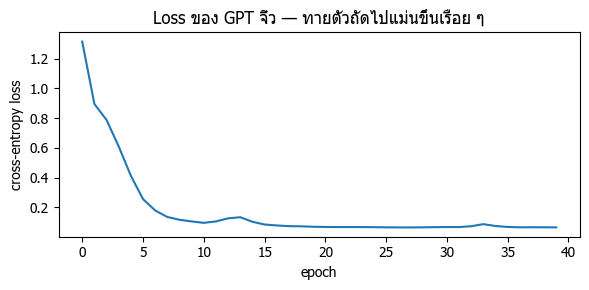

In [25]:
# ── ขั้น 4: train — โจทย์เดียวล้วน ๆ คือ "ทายตัวอักษรถัดไป" ──
history = gpt.fit(inputs, targets, batch_size=64, epochs=40, verbose=0)

print(f"loss: {history.history['loss'][0]:.4f} (เริ่ม)  →  {history.history['loss'][-1]:.4f} (จบ)")

plt.figure(figsize=(6, 3))
plt.plot(history.history["loss"])
plt.xlabel("epoch")
plt.ylabel("cross-entropy loss")
plt.title("Loss ของ GPT จิ๋ว — ทายตัวถัดไปแม่นขึ้นเรื่อย ๆ")
plt.tight_layout()
plt.show()

In [26]:
# ── ขั้น 5: generate ข้อความ — autoregressive sampling ──

def generate(model, prompt, n_chars=160, temperature=0.5, seed=0):
    """สร้างข้อความต่อจาก prompt ทีละตัวอักษร"""
    rng = np.random.default_rng(seed)
    ids = [char2id[c] for c in prompt]               # encode prompt เป็น token id
    for _ in range(n_chars):
        context = ids[-SEQ_LEN:]                     # มองย้อนหลังได้สูงสุด SEQ_LEN ตัว (context window!)

        # forward ผ่านโมเดล → เอา logits เฉพาะ "ตำแหน่งสุดท้าย" = คะแนนของตัวอักษรถัดไป
        logits = model(np.array([context]), training=False).numpy()[0, -1]

        # temperature: หาร logits ก่อน softmax
        #   ต่ำ → การแจกแจงแหลม เลือกแต่ตัวที่มั่นใจ (ข้อความนิ่งแต่ซ้ำซาก)
        #   สูง → การแจกแจงแบน สุ่มหลากหลาย (สร้างสรรค์แต่เสี่ยงเพี้ยน)
        logits = logits / temperature
        probs = np.exp(logits - logits.max())        # softmax (ลบ max กัน overflow)
        probs = probs / probs.sum()

        next_id = int(rng.choice(vocab_size, p=probs))  # "สุ่ม" ตามความน่าจะเป็น ไม่ใช่เลือกตัวสูงสุดเสมอ
        ids.append(next_id)                          # ต่อท้ายแล้ววนทายตัวถัดไป — autoregressive
    return "".join(id2char[i] for i in ids)

print("=== temperature 0.3 — มั่นใจ เกาะ pattern ของ corpus แน่น ===")
print(generate(gpt, "the cat ", temperature=0.3))
print()
print("=== temperature 1.5 — สุ่มจัด เริ่มหลุดเป็นคำประหลาด ===")
print(generate(gpt, "the cat ", temperature=1.5))

=== temperature 0.3 — มั่นใจ เกาะ pattern ของ corpus แน่น ===


the cat sat on the mat. the dog sat on the log. the cat saw the dog and ran to the mat. the dog saw the cat and ran to the log. the cat and the dog sat on the mat. the 

=== temperature 1.5 — สุ่มจัด เริ่มหลุดเป็นคำประหลาด ===


the cat sat on the dog sat on the on the log. the cat saw the dog and ran to the mat. the dog saw the e cat and rand to the log. the cat and the dog sat og. the saw the


---
## 🎓 สรุป — เส้นทางที่เดินมาทั้งหมด

| Part | สิ่งที่สร้าง | บทเรียนสำคัญ |
|---|---|---|
| 0 | linear regression | วงจร **forward → loss → gradient → update** คือหัวใจของทุกโมเดล |
| 1 | neuron เดี่ยว | โมเดล linear มีเพดาน — XOR ก็เอาไม่อยู่ |
| 2 | MLP + backprop ด้วยมือ | **chain rule** คือกลไกการเรียนรู้ของทั้งวงการ |
| 3 | เวอร์ชัน vectorized | deep learning = การคูณ matrix (เหตุผลที่ต้องใช้ GPU) |
| 4 | Keras + MNIST | เครื่องมือจริงห่อทุกอย่างที่เราเขียนเองไว้ให้หมดแล้ว |
| 5 | ทดลอง overfitting | ตัวเลขที่เชื่อถือได้มีอย่างเดียว: ผลบน**ข้อมูลที่โมเดลไม่เคยเห็น** |
| 6 | CNN + confusion matrix | เลือกสถาปัตยกรรมให้เข้ากับข้อมูล และเลือก metric ให้เข้ากับงาน |
| 7 | attention (Q, K, V) | token มองกันเองเพื่อเข้าใจบริบท + causal mask สำหรับ LLM |
| 8 | mini GPT | LLM = "ทาย token ถัดไป" วนซ้ำ ๆ — แค่นั้นจริง ๆ |

**GPT จิ๋วของเรา vs LLM จริง — ต่างกันแค่ "สเกล" ไม่ใช่ "หลักการ":**

| | GPT จิ๋วใน notebook นี้ | LLM ระดับ production |
|---|---|---|
| tokenizer | 16 ตัวอักษร | BPE ~100,000 subword |
| d_model | 64 | หลักพันถึงหมื่น |
| transformer blocks | 2 | ~30–100+ |
| parameters | ~แสนตัว | หลักพันล้านถึงล้านล้าน |
| ข้อมูล train | ~800 ตัวอักษร | หลายล้านล้าน token |
| ขั้นตอนเพิ่มเติม | — | RLHF / instruction tuning ให้คุยรู้เรื่องและปลอดภัย |

### แหล่งเรียนรู้ต่อ
- 📄 *Attention Is All You Need* (Vaswani et al., 2017) — paper ต้นตำรับ Transformer
- 🎬 Andrej Karpathy — *"Let's build GPT from scratch"* (YouTube) + repo **nanoGPT**
- 🎬 3Blue1Brown — ซีรีส์ *Neural Networks* (ภาพสวยมาก เข้าใจ backprop ลึกขึ้น)
- 📚 [d2l.ai](https://d2l.ai) — *Dive into Deep Learning* (หนังสือฟรี มีโค้ดทุกบท)